In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

import statsmodels.formula.api as smf

%load_ext autoreload
%autoreload 2

import utils.columns as cols
import utils.transform as transform
import utils.univariate as univar
import utils.bivariate as bivar
import utils.linear_regression as linear
import utils.experiment as experiment


# Read Preprocessed Mental, Social, and Green Space Datasets

In [2]:
# Define the base directory
BASE_PATH = '../final_data/processed'

# Load datasets using a dictionary comprehension
files = {
    'mental': f'{BASE_PATH}/medical/basis/mental_health_dataset_b.xlsx',
    'social': f'{BASE_PATH}/medical/basis/social_factors_dataset_b.xlsx',
    'green': f'{BASE_PATH}/environmental/basis/green_space_dataset_b.xlsx'
}

datasets = {name: pd.read_excel(path, index_col=0) for name, path in files.items()}

# Combine all datasets at once along the index (columns/horizontal alignment)
data_complete = pd.concat(datasets.values(), axis=1, join='outer')


In [3]:
data_complete = transform.rename_columns(data_complete)

# Age grouping

In [4]:
data_complete['Age_group'] = transform.categorize(
    data_complete, 'Age', bins=[0,40,53,65,np.inf], right=False, labels=["[18, 40)","[40, 53)","[53, 65)","[65, 81)"]
)

# Outcome Direction Map

In [5]:
outcome_direction_map = {
    "CES-D Score":  {"direction": "higher_is_worse", "label": "more severe depressive symptoms"},
    "GAD-7 Score":  {"direction": "higher_is_worse", "label": "more severe anxiety symptoms"},
    "SWLS Score":   {"direction": "higher_is_better", "label": "better life satisfaction"},
}

# Linear Model: Mental Health Scores across Green Exposures

## NDVI – continuous

In [8]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.ndvi

results_df, model_store = experiment.run_linear_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Score × NDVI (100m Buffer)
  [2/12] CES-D Score × NDVI (200m Buffer)
  [3/12] CES-D Score × NDVI (500m Buffer)
  [4/12] CES-D Score × NDVI (1000m Buffer)
  [5/12] GAD-7 Score × NDVI (100m Buffer)
  [6/12] GAD-7 Score × NDVI (200m Buffer)
  [7/12] GAD-7 Score × NDVI (500m Buffer)
  [8/12] GAD-7 Score × NDVI (1000m Buffer)
  [9/12] SWLS Score × NDVI (100m Buffer)
  [10/12] SWLS Score × NDVI (200m Buffer)
  [11/12] SWLS Score × NDVI (500m Buffer)
  [12/12] SWLS Score × NDVI (1000m Buffer)

  Linear grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,scale_predictor,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
0,CES-D Score,NDVI (100m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.278,0.086,-0.446,-0.111,"-0.278 (-0.446, -0.111)",-3.251,1.148681e-03,0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3
1,CES-D Score,NDVI (200m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.379,0.089,-0.554,-0.203,"-0.379 (-0.554, -0.203)",-4.234,2.297877e-05,<0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3
2,CES-D Score,NDVI (500m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.378,0.092,-0.558,-0.197,"-0.378 (-0.558, -0.197)",-4.105,4.041276e-05,<0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3
3,CES-D Score,NDVI (1000m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.333,0.099,-0.527,-0.139,"-0.333 (-0.527, -0.139)",-3.363,7.713810e-04,<0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3
4,GAD-7 Score,NDVI (100m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.058,0.041,-0.138,0.022,"-0.058 (-0.138, 0.022)",-1.427,1.535848e-01,0.154,"Age, Sex, Socioeconomic Status (Tiers)",HC3
5,GAD-7 Score,NDVI (200m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.068,0.043,-0.153,0.016,"-0.068 (-0.153, 0.016)",-1.578,1.145207e-01,0.115,"Age, Sex, Socioeconomic Status (Tiers)",HC3
6,GAD-7 Score,NDVI (500m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.129,0.044,-0.216,-0.042,"-0.129 (-0.216, -0.042)",-2.897,3.771791e-03,0.004,"Age, Sex, Socioeconomic Status (Tiers)",HC3
7,GAD-7 Score,NDVI (1000m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.137,0.047,-0.230,-0.044,"-0.137 (-0.230, -0.044)",-2.887,3.883480e-03,0.004,"Age, Sex, Socioeconomic Status (Tiers)",HC3
8,SWLS Score,NDVI (100m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (100m Buffer),0.511,0.066,0.382,0.640,"0.511 (0.382, 0.640)",7.759,8.574554e-15,<0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3
9,SWLS Score,NDVI (200m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (200m Buffer),0.610,0.069,0.474,0.747,"0.610 (0.474, 0.747)",8.784,1.571602e-18,<0.001,"Age, Sex, Socioeconomic Status (Tiers)",HC3


## Save Linear Regression results to `linear_results` in `pkl` and `csv`

In [9]:
##out_path = f"outputs/linear/mental_numeric/ndvi/adjusted/linear_results"
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/linear/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/mental_numeric/ndvi/adjusted/linear_results.csv


## Land-use-based Green Space – Quartiles

In [12]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.greenspace_quartiles

results_df, model_store = experiment.run_linear_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)
  [5/12] GAD-7 Score × Green Space Quartile (100m Buffer)
  [6/12] GAD-7 Score × Green Space Quartile (200m Buffer)
  [7/12] GAD-7 Score × Green Space Quartile (500m Buffer)
  [8/12] GAD-7 Score × Green Space Quartile (1000m Buffer)
  [9/12] SWLS Score × Green Space Quartile (100m Buffer)
  [10/12] SWLS Score × Green Space Quartile (200m Buffer)
  [11/12] SWLS Score × Green Space Quartile (500m Buffer)
  [12/12] SWLS Score × Green Space Quartile (1000m Buffer)

  Linear grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,reference_category,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
0,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.136,0.210,-0.548,0.277,"-0.136 (-0.548, 0.277)",-0.645,5.188761e-01,0.519,"Age, Sex, Socioeconomic Status (Tiers)",HC3
1,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.248,0.211,-0.662,0.165,"-0.248 (-0.662, 0.165)",-1.176,2.394920e-01,0.239,"Age, Sex, Socioeconomic Status (Tiers)",HC3
2,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.543,0.202,-0.938,-0.148,"-0.543 (-0.938, -0.148)",-2.693,7.086678e-03,0.007,"Age, Sex, Socioeconomic Status (Tiers)",HC3
3,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.286,0.214,-0.705,0.132,"-0.286 (-0.705, 0.132)",-1.340,1.801569e-01,0.180,"Age, Sex, Socioeconomic Status (Tiers)",HC3
4,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.628,0.209,-1.036,-0.219,"-0.628 (-1.036, -0.219)",-3.010,2.614477e-03,0.003,"Age, Sex, Socioeconomic Status (Tiers)",HC3
5,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.627,0.203,-1.026,-0.228,"-0.627 (-1.026, -0.228)",-3.083,2.048054e-03,0.002,"Age, Sex, Socioeconomic Status (Tiers)",HC3
6,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.109,0.211,-0.523,0.305,"-0.109 (-0.523, 0.305)",-0.517,6.053463e-01,0.605,"Age, Sex, Socioeconomic Status (Tiers)",HC3
7,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.285,0.206,-0.687,0.118,"-0.285 (-0.687, 0.118)",-1.385,1.660909e-01,0.166,"Age, Sex, Socioeconomic Status (Tiers)",HC3
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.438,0.203,-0.837,-0.039,"-0.438 (-0.837, -0.039)",-2.152,3.141775e-02,0.031,"Age, Sex, Socioeconomic Status (Tiers)",HC3
9,CES-D Score,Green Space Quartile (1000m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.108,0.211,-0.521,0.305,"-0.108 (-0.521, 0.305)",-0.513,6.079931e-01,0.608,"Age, Sex, Socioeconomic Status (Tiers)",HC3


## Save Linear Regression results to `linear_results` in `pkl` and `csv`

In [13]:
##out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results"
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/linear/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/mental_numeric/quartiles/adjusted/linear_results.csv


# Load Linear Model results from `linear_results.pkl`

In [ ]:
##out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results" ## ndvi | quartiles
##results_df, model_store = experiment.load_results(out_path)

# Analysis – Mental Scores vs. Green Exposures

## NDVI – Linear model – unadjusted

In [14]:
out_path = f"outputs/linear/mental_numeric/ndvi/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

#results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]
results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T12:54:56.150388


,outcome,predictor,predictor_type,n,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
2,CES-D Score,NDVI (500m Buffer),continuous,9142,0.1,-0.413,"-0.413 (-0.600, -0.227)",0.095,-4.352,<0.001,unadjusted
6,GAD-7 Score,NDVI (500m Buffer),continuous,9304,0.1,-0.162,"-0.162 (-0.250, -0.074)",0.045,-3.605,<0.001,unadjusted
10,SWLS Score,NDVI (500m Buffer),continuous,9323,0.1,0.679,"0.679 (0.535, 0.822)",0.073,9.256,<0.001,unadjusted


## NDVI – Linear model – adjusted: Sex, Age, SES

In [15]:
out_path = f"outputs/linear/mental_numeric/ndvi/adjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T12:55:07.088235


,outcome,predictor,predictor_type,n,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
2,CES-D Score,NDVI (500m Buffer),continuous,9117,0.1,-0.378,"-0.378 (-0.558, -0.197)",0.092,-4.105,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Score,NDVI (500m Buffer),continuous,9278,0.1,-0.129,"-0.129 (-0.216, -0.042)",0.044,-2.897,0.004,"Age, Sex, Socioeconomic Status (Tiers)"
10,SWLS Score,NDVI (500m Buffer),continuous,9297,0.1,0.561,"0.561 (0.422, 0.700)",0.071,7.894,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"


## Land-use-based Quartiles – Linear model – unadjusted

In [16]:
out_path = f"outputs/linear/mental_numeric/quartiles/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T12:55:34.253653


,outcome,predictor,predictor_type,n,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9104,Q1,Q4,-0.793,"-0.793 (-1.205, -0.382)",0.210,-3.783,<0.001,unadjusted
20,GAD-7 Score,Green Space Quartile (500m Buffer),categorical,9264,Q1,Q4,-0.251,"-0.251 (-0.444, -0.057)",0.099,-2.537,0.011,unadjusted
32,SWLS Score,Green Space Quartile (500m Buffer),categorical,9283,Q1,Q4,1.480,"1.480 (1.163, 1.796)",0.161,9.172,<0.001,unadjusted


## Land-use-based Quartiles – Linear model – adjusted: Sex, Age, SES

In [17]:
out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T12:55:46.358928


,outcome,predictor,predictor_type,n,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,Q1,Q4,-0.438,"-0.438 (-0.837, -0.039)",0.203,-2.152,0.031,"Age, Sex, Socioeconomic Status (Tiers)"
20,GAD-7 Score,Green Space Quartile (500m Buffer),categorical,9238,Q1,Q4,-0.148,"-0.148 (-0.339, 0.044)",0.098,-1.514,0.130,"Age, Sex, Socioeconomic Status (Tiers)"
32,SWLS Score,Green Space Quartile (500m Buffer),categorical,9257,Q1,Q4,1.156,"1.156 (0.847, 1.464)",0.157,7.344,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"


# Plot FOREST – Mental Scores vs. Green Exposure Quartiles

  Loaded results saved at: 2026-09-14T12:55:34.253653


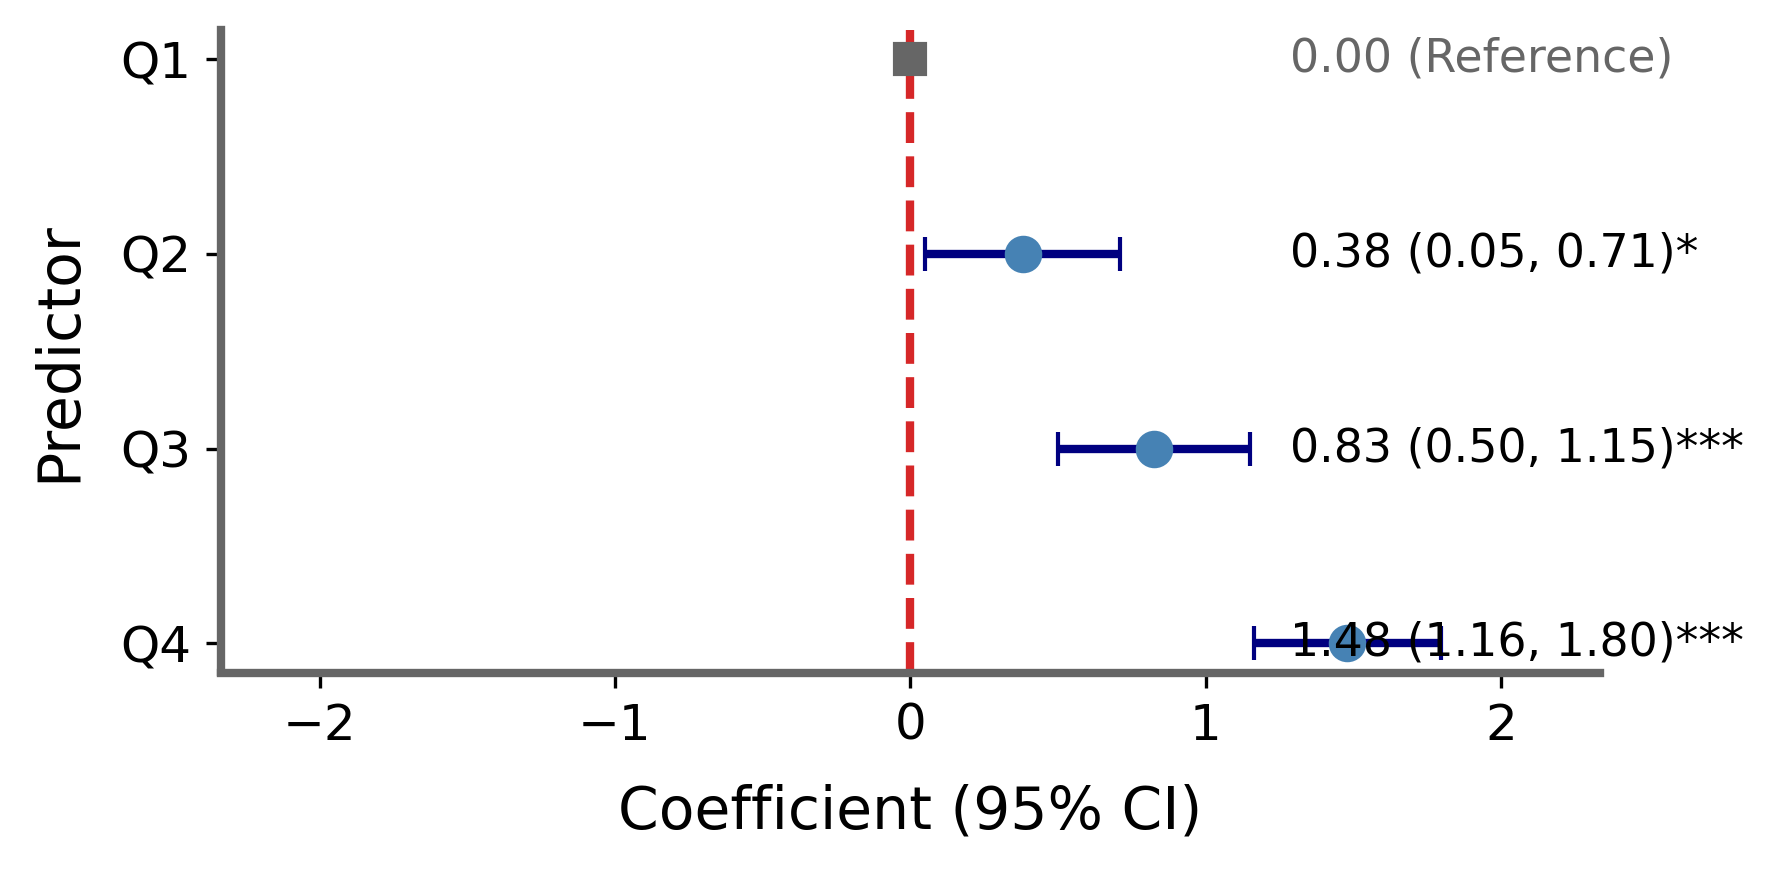

In [18]:
out_path = f"outputs/linear/mental_numeric/quartiles/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric[2]
predictor = cols.greenspace_quartiles[2]
df_plot = results_df.query(f"outcome == @outcome and predictor == @predictor")
linear.plot_forest(df_plot)#, save_path='out.png')

# Linear Model – Single Mental Health Variable

In [19]:
data = data_complete.copy()

outcome = cols.mental_numeric[2]
predictor = cols.greenspace_quartiles[1]
#predictor = cols.ndvi[2]

result, metadata = linear.fit_model(data, outcome, predictor, predictor_type="categorical")#, covariates=['Sex', 'Age'])

In [20]:
results_df = linear.extract_results(
    result,
    metadata
)
print(f"outcome: {metadata['outcome']}, \npredictor: {metadata['predictor']}")
display(results_df)

outcome: SWLS Score, 
predictor: Green Space Quartile (200m Buffer)


,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
0,Q1,Q2,0.488,0.169,0.156,0.819,"0.488 (0.156, 0.819)",2.883,3.935650e-03,0.004,unadjusted,HC3
1,Q1,Q3,0.861,0.167,0.534,1.187,"0.861 (0.534, 1.187)",5.164,2.417283e-07,<0.001,unadjusted,HC3
2,Q1,Q4,1.599,0.162,1.281,1.916,"1.599 (1.281, 1.916)",9.874,5.416265e-23,<0.001,unadjusted,HC3


# Stratified Linear Model – Experiments

## SES-stratified: Mental Scores across NDVI

In [31]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.ndvi

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "linear",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Score × NDVI (100m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Score × NDVI (200m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Score × NDVI (500m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Score × NDVI (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0 

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,scale_predictor,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
0,CES-D Score,NDVI (100m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.219,0.217,-0.644,0.206,"-0.219 (-0.644, 0.206)",-1.011,3.121520e-01,0.312,"Sex, Age",HC3
1,CES-D Score,NDVI (100m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.249,0.112,-0.468,-0.030,"-0.249 (-0.468, -0.030)",-2.226,2.601288e-02,0.026,"Sex, Age",HC3
2,CES-D Score,NDVI (100m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.369,0.163,-0.689,-0.050,"-0.369 (-0.689, -0.050)",-2.265,2.352648e-02,0.024,"Sex, Age",HC3
3,CES-D Score,NDVI (200m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.405,0.226,-0.849,0.038,"-0.405 (-0.849, 0.038)",-1.792,7.310964e-02,0.073,"Sex, Age",HC3
4,CES-D Score,NDVI (200m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.361,0.119,-0.595,-0.127,"-0.361 (-0.595, -0.127)",-3.030,2.447596e-03,0.002,"Sex, Age",HC3
5,CES-D Score,NDVI (200m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.355,0.164,-0.677,-0.032,"-0.355 (-0.677, -0.032)",-2.157,3.100241e-02,0.031,"Sex, Age",HC3
6,CES-D Score,NDVI (500m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.614,0.224,-1.052,-0.176,"-0.614 (-1.052, -0.176)",-2.748,6.001298e-03,0.006,"Sex, Age",HC3
7,CES-D Score,NDVI (500m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.352,0.123,-0.594,-0.110,"-0.352 (-0.594, -0.110)",-2.851,4.358415e-03,0.004,"Sex, Age",HC3
8,CES-D Score,NDVI (500m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.224,0.174,-0.564,0.117,"-0.224 (-0.564, 0.117)",-1.288,1.975787e-01,0.198,"Sex, Age",HC3
9,CES-D Score,NDVI (1000m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.677,0.256,-1.179,-0.175,"-0.677 (-1.179, -0.175)",-2.641,8.268040e-03,0.008,"Sex, Age",HC3


## Save Stratified Regression results to `linear_results` in `pkl` and `csv`

In [32]:
##out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results.csv


## SES-Stratified: Mental Scores across Green Space Quartiles

In [43]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.greenspace_quartiles

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "linear",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers)

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,reference_category,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
0,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q2,0.426,0.525,-0.602,1.455,"0.426 (-0.602, 1.455)",0.813,4.164285e-01,0.416,"Sex, Age",HC3
1,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q3,-0.284,0.547,-1.355,0.788,"-0.284 (-1.355, 0.788)",-0.519,6.036029e-01,0.604,"Sex, Age",HC3
2,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q4,-0.633,0.547,-1.706,0.439,"-0.633 (-1.706, 0.439)",-1.157,2.470727e-01,0.247,"Sex, Age",HC3
3,CES-D Score,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q2,-0.404,0.260,-0.914,0.106,"-0.404 (-0.914, 0.106)",-1.552,1.207811e-01,0.121,"Sex, Age",HC3
4,CES-D Score,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q3,-0.234,0.267,-0.757,0.290,"-0.234 (-0.757, 0.290)",-0.875,3.817966e-01,0.382,"Sex, Age",HC3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,SWLS Score,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q3,0.402,0.204,0.002,0.801,"0.402 (0.002, 0.801)",1.971,4.875443e-02,0.049,"Sex, Age",HC3
104,SWLS Score,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q4,1.345,0.195,0.963,1.728,"1.345 (0.963, 1.728)",6.901,5.174186e-12,<0.001,"Sex, Age",HC3
105,SWLS Score,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q2,0.156,0.327,-0.485,0.797,"0.156 (-0.485, 0.797)",0.477,6.333202e-01,0.633,"Sex, Age",HC3
106,SWLS Score,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q3,0.410,0.304,-0.186,1.007,"0.410 (-0.186, 1.007)",1.349,1.773589e-01,0.177,"Sex, Age",HC3


## Save Stratified Regression results to `linear_results` in `pkl` and `csv`

In [44]:
##out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results.csv


# Analysis – SES-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [45]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:15:26.941586


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
6,CES-D Score,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.706,"-0.706 (-1.146, -0.267)",0.224,-3.150,0.002,unadjusted
7,CES-D Score,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.290,"-0.290 (-0.532, -0.048)",0.123,-2.351,0.019,unadjusted
8,CES-D Score,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.210,"-0.210 (-0.550, 0.131)",0.174,-1.209,0.227,unadjusted
18,GAD-7 Score,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.342,"-0.342 (-0.562, -0.123)",0.112,-3.060,0.002,unadjusted
19,GAD-7 Score,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.118,"-0.118 (-0.233, -0.003)",0.059,-2.007,0.045,unadjusted
20,GAD-7 Score,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.071,"-0.071 (-0.240, 0.098)",0.086,-0.827,0.408,unadjusted
30,SWLS Score,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.577,"0.577 (0.204, 0.950)",0.190,3.033,0.002,unadjusted
31,SWLS Score,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.723,"0.723 (0.539, 0.907)",0.094,7.706,<0.001,unadjusted
32,SWLS Score,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.385,"0.385 (0.137, 0.632)",0.126,3.047,0.002,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [46]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:15:50.509183


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
6,CES-D Score,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.614,"-0.614 (-1.052, -0.176)",0.224,-2.748,0.006,"Sex, Age"
7,CES-D Score,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.352,"-0.352 (-0.594, -0.110)",0.123,-2.851,0.004,"Sex, Age"
8,CES-D Score,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.224,"-0.224 (-0.564, 0.117)",0.174,-1.288,0.198,"Sex, Age"
18,GAD-7 Score,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.279,"-0.279 (-0.498, -0.059)",0.112,-2.492,0.013,"Sex, Age"
19,GAD-7 Score,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.102,"-0.102 (-0.216, 0.013)",0.058,-1.741,0.082,"Sex, Age"
20,GAD-7 Score,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.063,"-0.063 (-0.230, 0.104)",0.085,-0.740,0.459,"Sex, Age"
30,SWLS Score,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.383,"0.383 (0.023, 0.742)",0.183,2.086,0.037,"Sex, Age"
31,SWLS Score,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.667,"0.667 (0.483, 0.851)",0.094,7.099,<0.001,"Sex, Age"
32,SWLS Score,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.390,"0.390 (0.143, 0.638)",0.126,3.090,0.002,"Sex, Age"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [47]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:20:10.141133


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
20,CES-D Score,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-1.811,"-1.811 (-2.821, -0.802)",0.515,-3.518,<0.001,unadjusted
23,CES-D Score,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.190,"-0.190 (-0.708, 0.329)",0.265,-0.717,0.473,unadjusted
26,CES-D Score,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.133,"-0.133 (-0.924, 0.657)",0.404,-0.331,0.741,unadjusted
56,GAD-7 Score,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.940,"-0.940 (-1.431, -0.450)",0.250,-3.756,<0.001,unadjusted
59,GAD-7 Score,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.004,"-0.004 (-0.255, 0.247)",0.128,-0.033,0.973,unadjusted
62,GAD-7 Score,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.086,"-0.086 (-0.455, 0.283)",0.188,-0.457,0.648,unadjusted
92,SWLS Score,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,1.652,"1.652 (0.822, 2.482)",0.423,3.901,<0.001,unadjusted
95,SWLS Score,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.297,"1.297 (0.898, 1.695)",0.203,6.373,<0.001,unadjusted
98,SWLS Score,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.709,"0.709 (0.119, 1.298)",0.301,2.356,0.018,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [48]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:20:55.930707


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
20,CES-D Score,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-1.609,"-1.609 (-2.613, -0.605)",0.512,-3.140,0.002,"Sex, Age"
23,CES-D Score,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.203,"-0.203 (-0.716, 0.309)",0.261,-0.779,0.436,"Sex, Age"
26,CES-D Score,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.174,"-0.174 (-0.964, 0.617)",0.403,-0.430,0.667,"Sex, Age"
56,GAD-7 Score,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.804,"-0.804 (-1.292, -0.316)",0.249,-3.230,0.001,"Sex, Age"
59,GAD-7 Score,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.026,"0.026 (-0.223, 0.274)",0.127,0.202,0.840,"Sex, Age"
62,GAD-7 Score,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.116,"-0.116 (-0.481, 0.249)",0.186,-0.623,0.533,"Sex, Age"
92,SWLS Score,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,1.284,"1.284 (0.475, 2.092)",0.412,3.113,0.002,"Sex, Age"
95,SWLS Score,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.266,"1.266 (0.869, 1.663)",0.203,6.249,<0.001,"Sex, Age"
98,SWLS Score,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.691,"0.691 (0.103, 1.278)",0.300,2.303,0.021,"Sex, Age"


# Analysis – Age-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [49]:
out_path = f"outputs/linear/stratified_age/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:14:04.293455


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,NDVI (500m Buffer),373,Age_group,"[18, 40)",0.1,0.048,"0.048 (-0.908, 1.004)",0.488,0.098,0.922,unadjusted
9,CES-D Score,NDVI (500m Buffer),3202,Age_group,"[40, 53)",0.1,-0.379,"-0.379 (-0.700, -0.058)",0.164,-2.317,0.021,unadjusted
10,CES-D Score,NDVI (500m Buffer),2649,Age_group,"[53, 65)",0.1,-0.578,"-0.578 (-0.936, -0.220)",0.183,-3.164,0.002,unadjusted
11,CES-D Score,NDVI (500m Buffer),2918,Age_group,"[65, 81)",0.1,-0.573,"-0.573 (-0.887, -0.259)",0.160,-3.581,<0.001,unadjusted
24,GAD-7 Score,NDVI (500m Buffer),375,Age_group,"[18, 40)",0.1,0.087,"0.087 (-0.330, 0.504)",0.213,0.410,0.682,unadjusted
25,GAD-7 Score,NDVI (500m Buffer),3237,Age_group,"[40, 53)",0.1,-0.167,"-0.167 (-0.317, -0.016)",0.077,-2.165,0.030,unadjusted
26,GAD-7 Score,NDVI (500m Buffer),2711,Age_group,"[53, 65)",0.1,-0.191,"-0.191 (-0.367, -0.015)",0.090,-2.122,0.034,unadjusted
27,GAD-7 Score,NDVI (500m Buffer),2981,Age_group,"[65, 81)",0.1,-0.158,"-0.158 (-0.304, -0.012)",0.075,-2.118,0.034,unadjusted
40,SWLS Score,NDVI (500m Buffer),377,Age_group,"[18, 40)",0.1,0.360,"0.360 (-0.283, 1.002)",0.328,1.098,0.272,unadjusted
41,SWLS Score,NDVI (500m Buffer),3241,Age_group,"[40, 53)",0.1,0.922,"0.922 (0.671, 1.173)",0.128,7.193,<0.001,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [50]:
out_path = f"outputs/linear/stratified_age/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:13:32.101632


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,NDVI (500m Buffer),365,Age_group,"[18, 40)",0.1,-0.031,"-0.031 (-0.946, 0.884)",0.467,-0.067,0.946,"Sex, Socioeconomic Status (Tiers)"
9,CES-D Score,NDVI (500m Buffer),3199,Age_group,"[40, 53)",0.1,-0.319,"-0.319 (-0.629, -0.009)",0.158,-2.016,0.044,"Sex, Socioeconomic Status (Tiers)"
10,CES-D Score,NDVI (500m Buffer),2644,Age_group,"[53, 65)",0.1,-0.450,"-0.450 (-0.800, -0.099)",0.179,-2.515,0.012,"Sex, Socioeconomic Status (Tiers)"
11,CES-D Score,NDVI (500m Buffer),2909,Age_group,"[65, 81)",0.1,-0.496,"-0.496 (-0.799, -0.193)",0.155,-3.206,0.001,"Sex, Socioeconomic Status (Tiers)"
24,GAD-7 Score,NDVI (500m Buffer),367,Age_group,"[18, 40)",0.1,0.020,"0.020 (-0.379, 0.418)",0.203,0.096,0.924,"Sex, Socioeconomic Status (Tiers)"
25,GAD-7 Score,NDVI (500m Buffer),3234,Age_group,"[40, 53)",0.1,-0.150,"-0.150 (-0.300, -0.001)",0.076,-1.975,0.048,"Sex, Socioeconomic Status (Tiers)"
26,GAD-7 Score,NDVI (500m Buffer),2706,Age_group,"[53, 65)",0.1,-0.175,"-0.175 (-0.349, 0.000)",0.089,-1.958,0.050,"Sex, Socioeconomic Status (Tiers)"
27,GAD-7 Score,NDVI (500m Buffer),2971,Age_group,"[65, 81)",0.1,-0.123,"-0.123 (-0.267, 0.022)",0.074,-1.665,0.096,"Sex, Socioeconomic Status (Tiers)"
40,SWLS Score,NDVI (500m Buffer),369,Age_group,"[18, 40)",0.1,0.384,"0.384 (-0.250, 1.018)",0.324,1.186,0.235,"Sex, Socioeconomic Status (Tiers)"
41,SWLS Score,NDVI (500m Buffer),3238,Age_group,"[40, 53)",0.1,0.867,"0.867 (0.631, 1.102)",0.120,7.208,<0.001,"Sex, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [51]:
out_path = f"outputs/linear/stratified_age/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:19:31.349341


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
26,CES-D Score,Green Space Quartile (500m Buffer),370,Age_group,"[18, 40)",Q1,Q4,1.388,"1.388 (-0.591, 3.366)",1.010,1.374,0.169,unadjusted
29,CES-D Score,Green Space Quartile (500m Buffer),3191,Age_group,"[40, 53)",Q1,Q4,-1.477,"-1.477 (-2.178, -0.776)",0.358,-4.129,<0.001,unadjusted
32,CES-D Score,Green Space Quartile (500m Buffer),2638,Age_group,"[53, 65)",Q1,Q4,-0.491,"-0.491 (-1.274, 0.292)",0.400,-1.228,0.219,unadjusted
35,CES-D Score,Green Space Quartile (500m Buffer),2905,Age_group,"[65, 81)",Q1,Q4,-0.717,"-0.717 (-1.426, -0.009)",0.361,-1.984,0.047,unadjusted
74,GAD-7 Score,Green Space Quartile (500m Buffer),372,Age_group,"[18, 40)",Q1,Q4,0.392,"0.392 (-0.549, 1.334)",0.480,0.817,0.414,unadjusted
77,GAD-7 Score,Green Space Quartile (500m Buffer),3225,Age_group,"[40, 53)",Q1,Q4,-0.550,"-0.550 (-0.872, -0.227)",0.165,-3.339,<0.001,unadjusted
80,GAD-7 Score,Green Space Quartile (500m Buffer),2700,Age_group,"[53, 65)",Q1,Q4,-0.173,"-0.173 (-0.553, 0.208)",0.194,-0.889,0.374,unadjusted
83,GAD-7 Score,Green Space Quartile (500m Buffer),2967,Age_group,"[65, 81)",Q1,Q4,-0.065,"-0.065 (-0.400, 0.269)",0.171,-0.383,0.702,unadjusted
122,SWLS Score,Green Space Quartile (500m Buffer),374,Age_group,"[18, 40)",Q1,Q4,0.449,"0.449 (-1.064, 1.962)",0.772,0.582,0.561,unadjusted
125,SWLS Score,Green Space Quartile (500m Buffer),3229,Age_group,"[40, 53)",Q1,Q4,2.350,"2.350 (1.810, 2.889)",0.275,8.536,<0.001,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [52]:
out_path = f"outputs/linear/stratified_age/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:19:12.083553


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
26,CES-D Score,Green Space Quartile (500m Buffer),362,Age_group,"[18, 40)",Q1,Q4,1.750,"1.750 (-0.308, 3.808)",1.050,1.667,0.096,"Sex, Socioeconomic Status (Tiers)"
29,CES-D Score,Green Space Quartile (500m Buffer),3188,Age_group,"[40, 53)",Q1,Q4,-1.010,"-1.010 (-1.687, -0.333)",0.345,-2.925,0.003,"Sex, Socioeconomic Status (Tiers)"
32,CES-D Score,Green Space Quartile (500m Buffer),2633,Age_group,"[53, 65)",Q1,Q4,-0.058,"-0.058 (-0.821, 0.705)",0.389,-0.149,0.882,"Sex, Socioeconomic Status (Tiers)"
35,CES-D Score,Green Space Quartile (500m Buffer),2896,Age_group,"[65, 81)",Q1,Q4,-0.444,"-0.444 (-1.132, 0.244)",0.351,-1.264,0.206,"Sex, Socioeconomic Status (Tiers)"
74,GAD-7 Score,Green Space Quartile (500m Buffer),364,Age_group,"[18, 40)",Q1,Q4,0.531,"0.531 (-0.442, 1.503)",0.496,1.069,0.285,"Sex, Socioeconomic Status (Tiers)"
77,GAD-7 Score,Green Space Quartile (500m Buffer),3222,Age_group,"[40, 53)",Q1,Q4,-0.435,"-0.435 (-0.756, -0.115)",0.164,-2.660,0.008,"Sex, Socioeconomic Status (Tiers)"
80,GAD-7 Score,Green Space Quartile (500m Buffer),2695,Age_group,"[53, 65)",Q1,Q4,-0.077,"-0.077 (-0.451, 0.298)",0.191,-0.401,0.688,"Sex, Socioeconomic Status (Tiers)"
83,GAD-7 Score,Green Space Quartile (500m Buffer),2957,Age_group,"[65, 81)",Q1,Q4,0.025,"0.025 (-0.305, 0.355)",0.168,0.151,0.880,"Sex, Socioeconomic Status (Tiers)"
122,SWLS Score,Green Space Quartile (500m Buffer),366,Age_group,"[18, 40)",Q1,Q4,0.294,"0.294 (-1.227, 1.816)",0.776,0.379,0.705,"Sex, Socioeconomic Status (Tiers)"
125,SWLS Score,Green Space Quartile (500m Buffer),3226,Age_group,"[40, 53)",Q1,Q4,1.858,"1.858 (1.347, 2.369)",0.261,7.129,<0.001,"Sex, Socioeconomic Status (Tiers)"


# Analysis – Sex-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [53]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:11:32.494791


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
4,CES-D Score,NDVI (500m Buffer),4441,Sex,0,0.1,-0.308,"-0.308 (-0.547, -0.068)",0.122,-2.515,0.012,unadjusted
5,CES-D Score,NDVI (500m Buffer),4701,Sex,1,0.1,-0.498,"-0.498 (-0.779, -0.216)",0.144,-3.468,<0.001,unadjusted
12,GAD-7 Score,NDVI (500m Buffer),4447,Sex,0,0.1,-0.165,"-0.165 (-0.286, -0.044)",0.062,-2.678,0.007,unadjusted
13,GAD-7 Score,NDVI (500m Buffer),4857,Sex,1,0.1,-0.148,"-0.148 (-0.274, -0.023)",0.064,-2.315,0.021,unadjusted
20,SWLS Score,NDVI (500m Buffer),4460,Sex,0,0.1,0.733,"0.733 (0.524, 0.943)",0.107,6.875,<0.001,unadjusted
21,SWLS Score,NDVI (500m Buffer),4863,Sex,1,0.1,0.630,"0.630 (0.432, 0.827)",0.101,6.244,<0.001,unadjusted


## Mental Scores vs. NDVI – adjusted: Age, SES

In [54]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T14:11:52.775046


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
4,CES-D Score,NDVI (500m Buffer),4432,Sex,0,0.1,-0.317,"-0.317 (-0.550, -0.084)",0.119,-2.665,0.008,"Age, Socioeconomic Status (Tiers)"
5,CES-D Score,NDVI (500m Buffer),4685,Sex,1,0.1,-0.436,"-0.436 (-0.710, -0.162)",0.140,-3.117,0.002,"Age, Socioeconomic Status (Tiers)"
12,GAD-7 Score,NDVI (500m Buffer),4436,Sex,0,0.1,-0.135,"-0.135 (-0.257, -0.014)",0.062,-2.188,0.029,"Age, Socioeconomic Status (Tiers)"
13,GAD-7 Score,NDVI (500m Buffer),4842,Sex,1,0.1,-0.124,"-0.124 (-0.249, 0.002)",0.064,-1.931,0.054,"Age, Socioeconomic Status (Tiers)"
20,SWLS Score,NDVI (500m Buffer),4449,Sex,0,0.1,0.582,"0.582 (0.378, 0.786)",0.104,5.599,<0.001,"Age, Socioeconomic Status (Tiers)"
21,SWLS Score,NDVI (500m Buffer),4848,Sex,1,0.1,0.529,"0.529 (0.338, 0.720)",0.098,5.420,<0.001,"Age, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [55]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:18:03.381882


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
14,CES-D Score,Green Space Quartile (500m Buffer),4424,Sex,0,Q1,Q4,-0.416,"-0.416 (-0.932, 0.101)",0.264,-1.576,0.115,unadjusted
17,CES-D Score,Green Space Quartile (500m Buffer),4680,Sex,1,Q1,Q4,-1.109,"-1.109 (-1.734, -0.484)",0.319,-3.478,<0.001,unadjusted
38,GAD-7 Score,Green Space Quartile (500m Buffer),4429,Sex,0,Q1,Q4,-0.167,"-0.167 (-0.431, 0.098)",0.135,-1.234,0.217,unadjusted
41,GAD-7 Score,Green Space Quartile (500m Buffer),4835,Sex,1,Q1,Q4,-0.296,"-0.296 (-0.572, -0.021)",0.141,-2.107,0.035,unadjusted
62,SWLS Score,Green Space Quartile (500m Buffer),4442,Sex,0,Q1,Q4,1.357,"1.357 (0.893, 1.821)",0.237,5.728,<0.001,unadjusted
65,SWLS Score,Green Space Quartile (500m Buffer),4841,Sex,1,Q1,Q4,1.603,"1.603 (1.171, 2.034)",0.220,7.273,<0.001,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [56]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T14:18:19.723055


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
14,CES-D Score,Green Space Quartile (500m Buffer),4415,Sex,0,Q1,Q4,-0.196,"-0.196 (-0.698, 0.306)",0.256,-0.766,0.444,"Age, Socioeconomic Status (Tiers)"
17,CES-D Score,Green Space Quartile (500m Buffer),4664,Sex,1,Q1,Q4,-0.657,"-0.657 (-1.271, -0.044)",0.313,-2.100,0.036,"Age, Socioeconomic Status (Tiers)"
38,GAD-7 Score,Green Space Quartile (500m Buffer),4418,Sex,0,Q1,Q4,-0.091,"-0.091 (-0.355, 0.173)",0.135,-0.677,0.499,"Age, Socioeconomic Status (Tiers)"
41,GAD-7 Score,Green Space Quartile (500m Buffer),4820,Sex,1,Q1,Q4,-0.204,"-0.204 (-0.480, 0.072)",0.141,-1.451,0.147,"Age, Socioeconomic Status (Tiers)"
62,SWLS Score,Green Space Quartile (500m Buffer),4431,Sex,0,Q1,Q4,1.022,"1.022 (0.570, 1.474)",0.231,4.432,<0.001,"Age, Socioeconomic Status (Tiers)"
65,SWLS Score,Green Space Quartile (500m Buffer),4826,Sex,1,Q1,Q4,1.254,"1.254 (0.832, 1.676)",0.215,5.822,<0.001,"Age, Socioeconomic Status (Tiers)"


# Stratified Linear Model – Single Mental Health Variable

In [57]:
data = data_complete.copy()

outcome   = "SWLS Score"
predictor = "Green Space Quartile (500m Buffer)"

strata_results, strata_summary = linear.fit_stratified(
    data               = data,
    outcome            = outcome,
    predictor          = predictor,
    stratify_by        = "Age_group",
#    strata             = [1, 2, 3],
    predictor_type     = "categorical",
    reference_category = "1.0",
    #covariates         = ["Sex", "Socioeconomic Status (Tiers)"],
)

display(strata_summary.query(f"level == 'Q4'"))

  Stratum Age_group = [18, 40)  (n = 513)
  Stratum Age_group = [40, 53)  (n = 3383)
  Stratum Age_group = [53, 65)  (n = 2851)
  Stratum Age_group = [65, 81)  (n = 3253)


,stratum,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates,cov_type
2,"[18, 40)",Q1,Q4,0.449,0.772,-1.064,1.962,"0.449 (-1.064, 1.962)",0.582,5.606511e-01,0.561,unadjusted,HC3
5,"[40, 53)",Q1,Q4,2.350,0.275,1.810,2.889,"2.350 (1.810, 2.889)",8.536,1.393759e-17,<0.001,unadjusted,HC3
8,"[53, 65)",Q1,Q4,1.400,0.310,0.792,2.008,"1.400 (0.792, 2.008)",4.514,6.348400e-06,<0.001,unadjusted,HC3
11,"[65, 81)",Q1,Q4,0.715,0.268,0.191,1.239,"0.715 (0.191, 1.239)",2.672,7.531182e-03,0.008,unadjusted,HC3


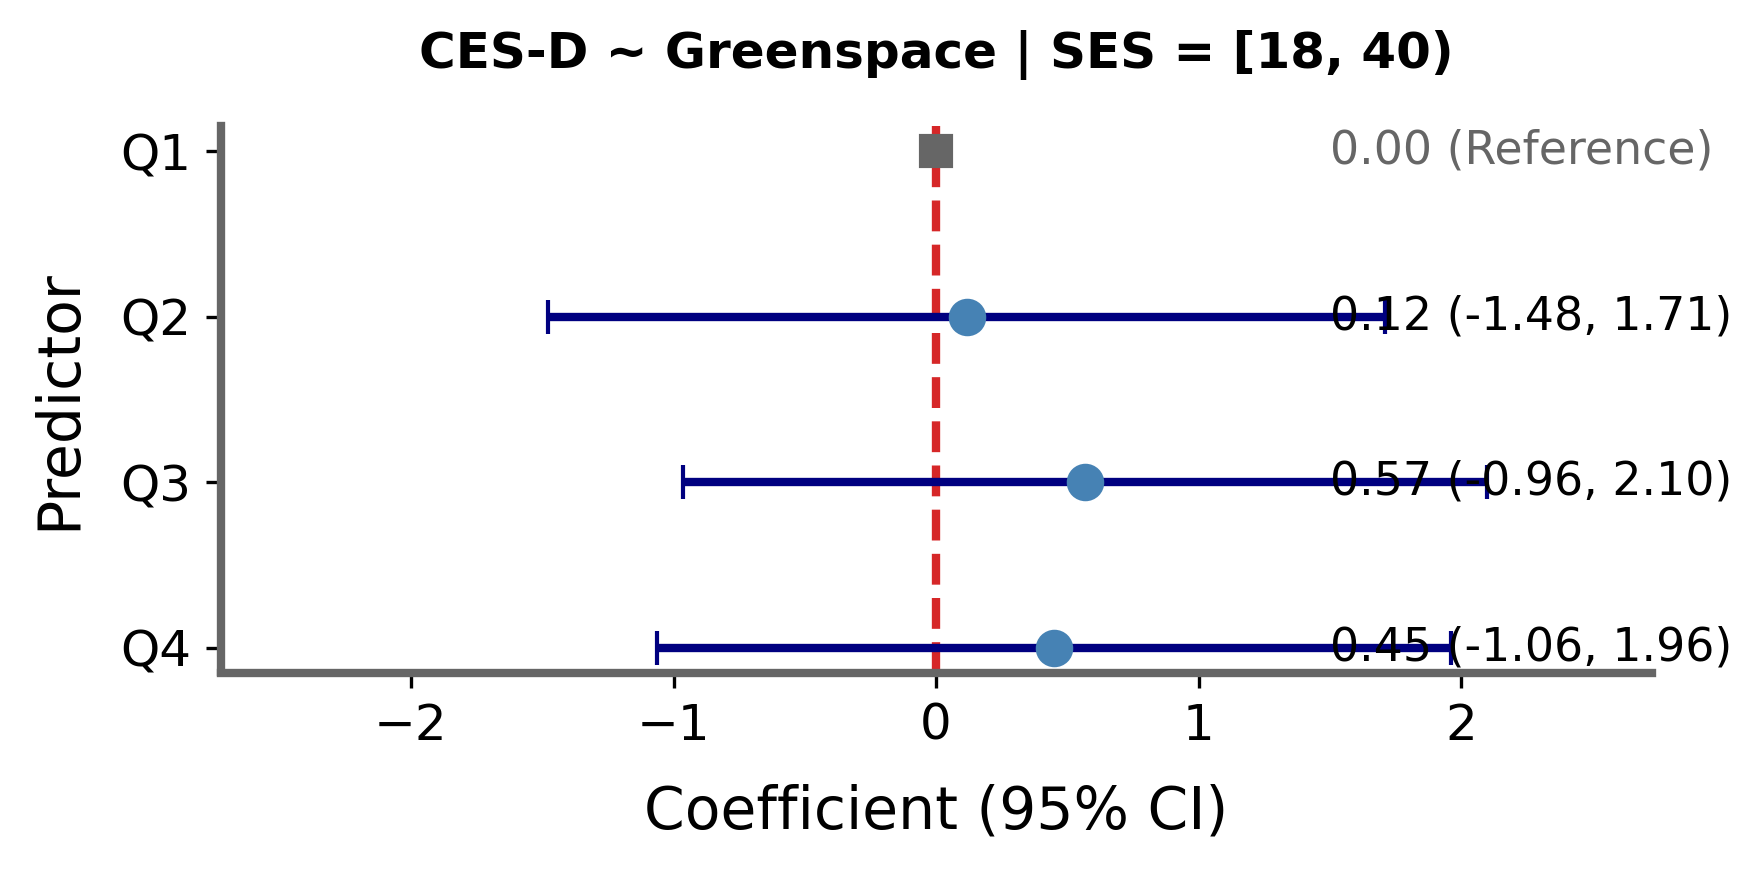

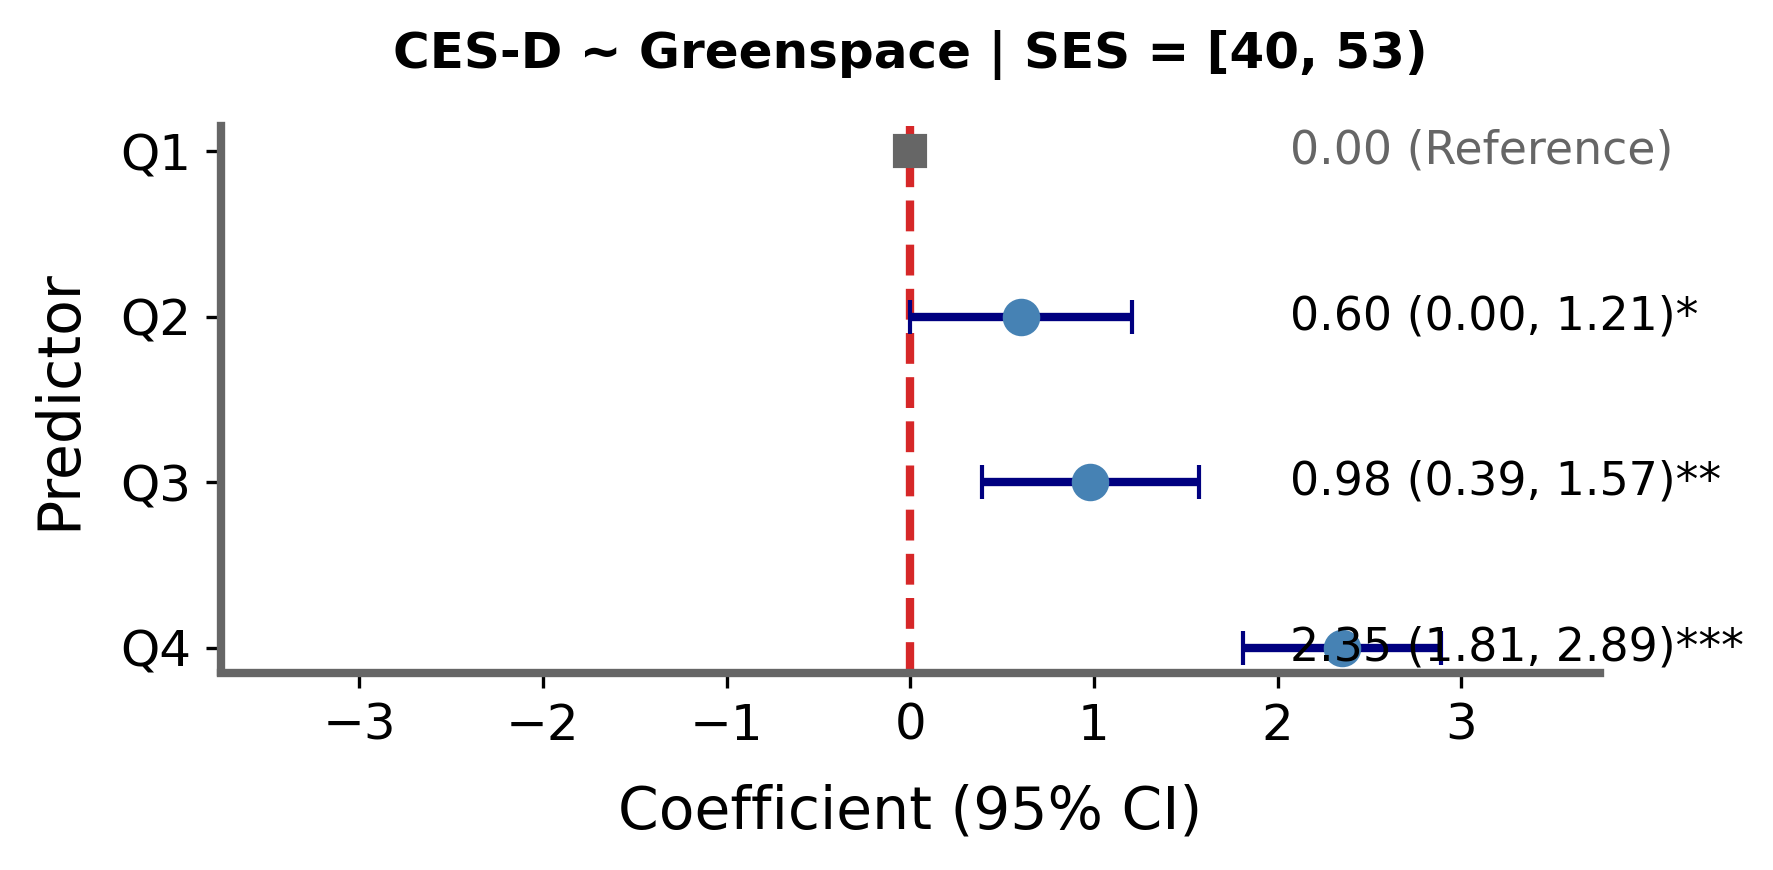

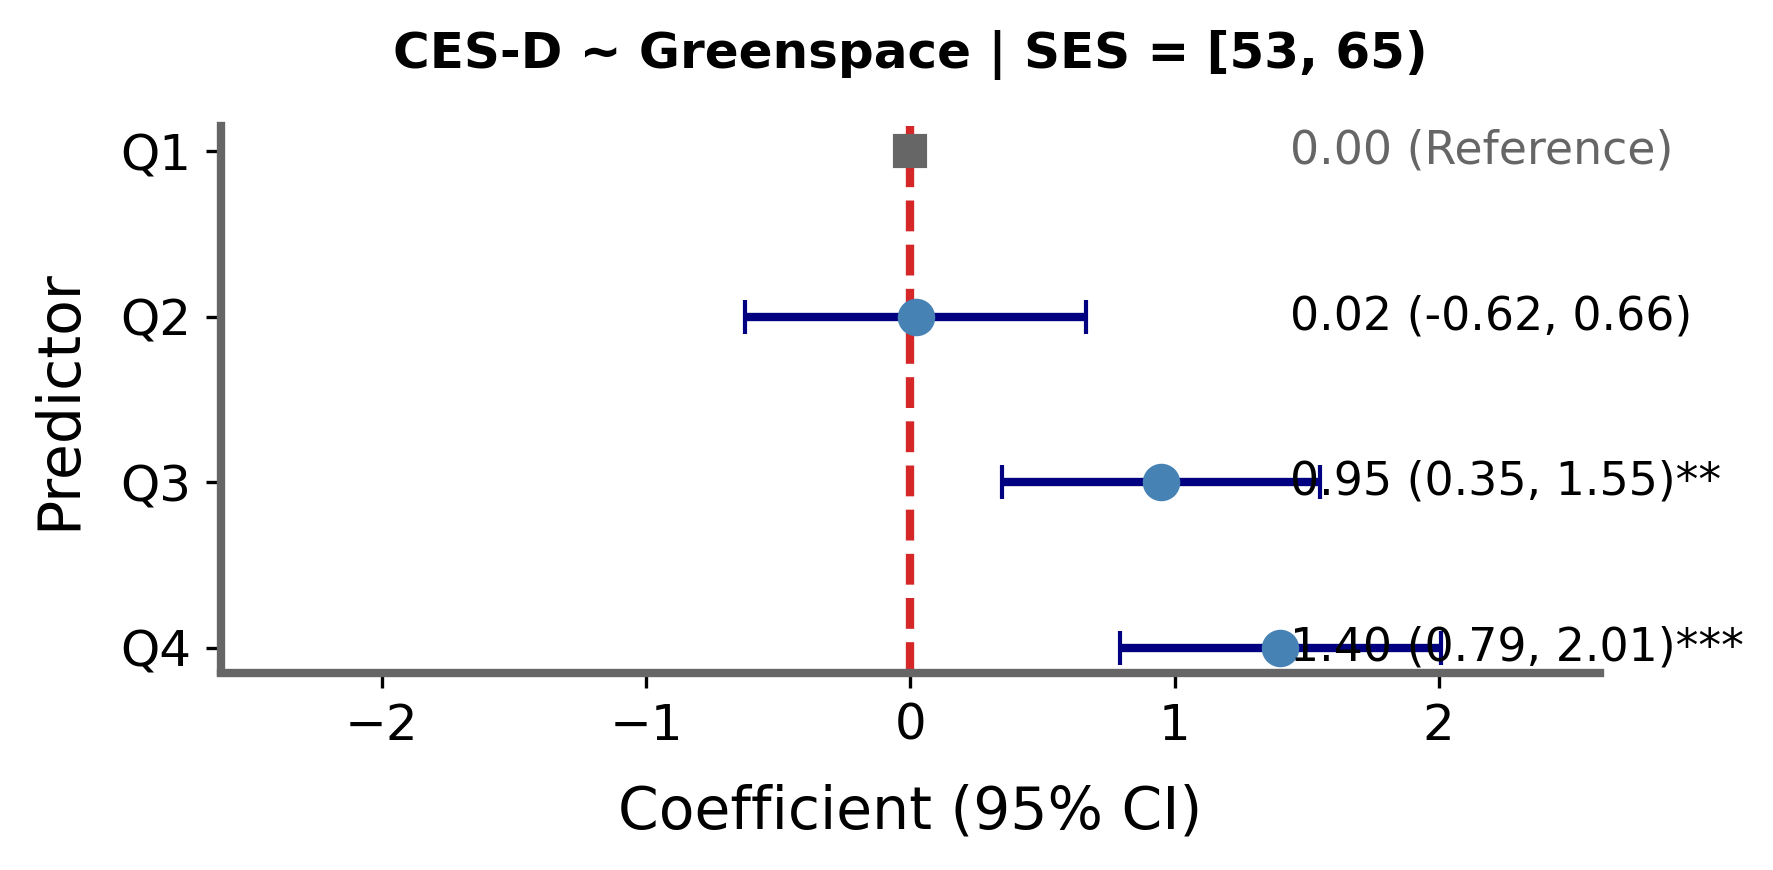

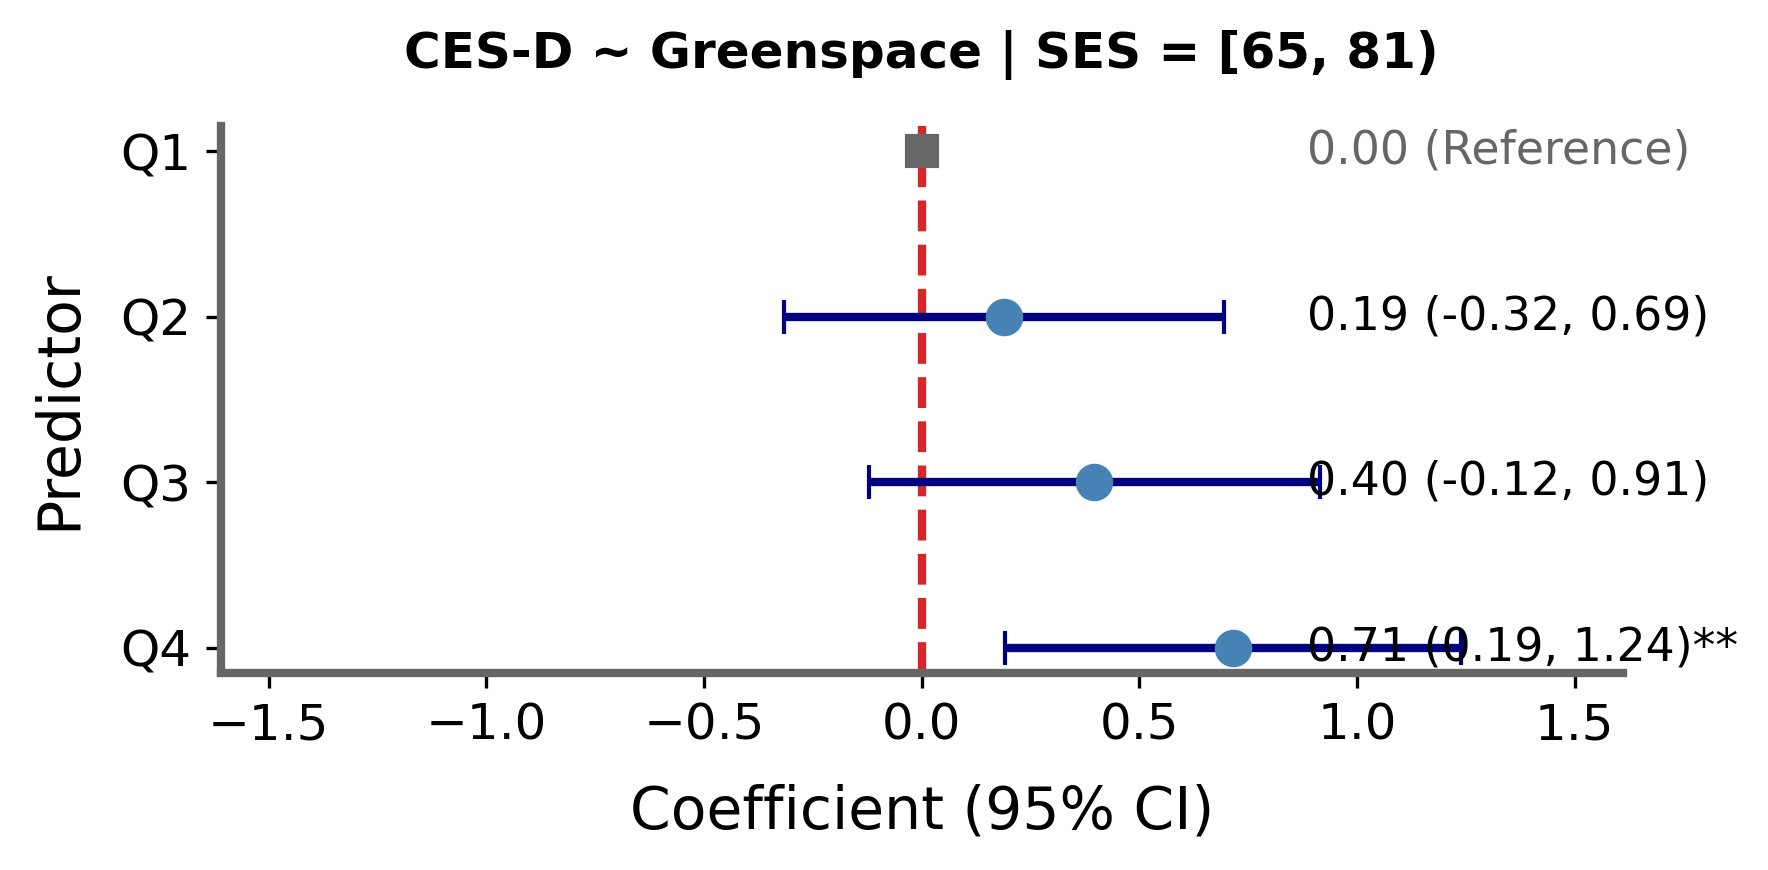

In [58]:
# Forest plot per stratum
for ses, res in strata_results.items():
    linear.plot_forest(
        res["beta_table"],
        title = f"CES-D ~ Greenspace | SES = {ses}",
        predictor_type = "categorical"
    )

# Interaction Linear Model – Experiments

## SES-moderator: Mental Scores across NDVI

In [69]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_numeric,
    predictors            = cols.ndvi,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "linear",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Score × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [2/12] CES-D Score × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [3/12] CES-D Score × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [4/12] CES-D Score × NDVI (1000m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 1/2 interaction terms p < 0.05
  [5/12] GAD-7 Score × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [6/12] GAD-7 Score × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [7/12] GAD-7 Score × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted 

,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.589,"0.589 (0.025, 1.152)",0.287,0.041,"Sex, Age",True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.308,"0.308 (0.036, 0.580)",0.139,0.027,"Sex, Age",True


## Save Interaction Model results to `linear_results` in `pkl` and `csv`

In [70]:
##out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results.csv


## SES-moderator: Mental Scores across Green Space Quartiles

In [85]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_numeric,
    predictors            = cols.greenspace_quartiles,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "linear",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 2/6 interaction terms p < 0.05
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [5/12] GAD-7 Score × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [6/12] GAD-7 Score × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [7/12] 

,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.615,"1.615 (0.488, 2.742)",0.575,0.005,"Sex, Age",True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.600,"1.600 (0.323, 2.878)",0.652,0.014,"Sex, Age",True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.905,"0.905 (0.358, 1.451)",0.279,0.001,"Sex, Age",True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.755,"0.755 (0.147, 1.363)",0.310,0.015,"Sex, Age",True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.642,"0.642 (0.021, 1.262)",0.317,0.043,"Sex, Age",True


## Save Interaction Model results to `linear_results` in `pkl` and `csv`

In [86]:
##out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results.csv


# Analysis – SES-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [87]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T16:03:38.710109


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.570,"0.570 (0.004, 1.136)",0.289,0.048,unadjusted,True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.306,"0.306 (0.031, 0.580)",0.140,0.029,unadjusted,True


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [88]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T16:04:38.030891


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.589,"0.589 (0.025, 1.152)",0.287,0.041,"Sex, Age",True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.308,"0.308 (0.036, 0.580)",0.139,0.027,"Sex, Age",True


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [89]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:11:38.526607


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.622,"1.622 (0.487, 2.756)",0.579,0.005,unadjusted,True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.678,"1.678 (0.396, 2.960)",0.654,0.010,unadjusted,True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.936,"0.936 (0.385, 1.487)",0.281,<0.001,unadjusted,True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.854,"0.854 (0.241, 1.468)",0.313,0.006,unadjusted,True
43,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q3,0.588,"0.588 (0.026, 1.149)",0.287,0.040,unadjusted,True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.669,"0.669 (0.039, 1.299)",0.321,0.037,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [90]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:11:51.000488


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.615,"1.615 (0.488, 2.742)",0.575,0.005,"Sex, Age",True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.600,"1.600 (0.323, 2.878)",0.652,0.014,"Sex, Age",True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.905,"0.905 (0.358, 1.451)",0.279,0.001,"Sex, Age",True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.755,"0.755 (0.147, 1.363)",0.310,0.015,"Sex, Age",True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.642,"0.642 (0.021, 1.262)",0.317,0.043,"Sex, Age",True


# Analysis – Age-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [91]:
out_path = f"outputs/linear/interaction_age/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T16:02:18.561282


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [92]:
out_path = f"outputs/linear/interaction_age/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T16:02:34.267345


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [93]:
out_path = f"outputs/linear/interaction_age/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:10:44.359181


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
0,CES-D Score,Green Space Quartile (100m Buffer),9104,Age_group,"[40, 53)",Q1,Q2,1.990,"1.990 (0.222, 3.758)",0.902,0.027,unadjusted,True
11,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-2.629,"-2.629 (-5.178, -0.080)",1.301,0.043,unadjusted,True
14,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[53, 65)",Q1,Q4,-3.066,"-3.066 (-5.648, -0.485)",1.317,0.020,unadjusted,True
17,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-2.570,"-2.570 (-5.125, -0.016)",1.303,0.049,unadjusted,True
20,CES-D Score,Green Space Quartile (500m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-2.865,"-2.865 (-4.964, -0.765)",1.071,0.007,unadjusted,True
26,CES-D Score,Green Space Quartile (500m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-2.105,"-2.105 (-4.207, -0.003)",1.072,0.050,unadjusted,True
47,GAD-7 Score,Green Space Quartile (200m Buffer),9264,Age_group,"[40, 53)",Q1,Q4,-1.193,"-1.193 (-2.311, -0.076)",0.570,0.036,unadjusted,True
50,GAD-7 Score,Green Space Quartile (200m Buffer),9264,Age_group,"[53, 65)",Q1,Q4,-1.256,"-1.256 (-2.392, -0.121)",0.579,0.030,unadjusted,True
80,SWLS Score,Green Space Quartile (100m Buffer),9283,Age_group,"[65, 81)",Q1,Q4,-1.414,"-1.414 (-2.825, -0.003)",0.720,0.050,unadjusted,True
92,SWLS Score,Green Space Quartile (500m Buffer),9283,Age_group,"[40, 53)",Q1,Q4,1.901,"1.901 (0.294, 3.507)",0.820,0.020,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [94]:
out_path = f"outputs/linear/interaction_age/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:11:02.094761


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (200m Buffer),9079,Age_group,"[53, 65)",Q1,Q4,-2.597,"-2.597 (-5.189, -0.006)",1.322,0.049,"Sex, Socioeconomic Status (Tiers)",True
20,CES-D Score,Green Space Quartile (500m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-2.784,"-2.784 (-4.942, -0.626)",1.101,0.011,"Sex, Socioeconomic Status (Tiers)",True
50,GAD-7 Score,Green Space Quartile (200m Buffer),9238,Age_group,"[53, 65)",Q1,Q4,-1.105,"-1.105 (-2.202, -0.009)",0.559,0.048,"Sex, Socioeconomic Status (Tiers)",True
80,SWLS Score,Green Space Quartile (100m Buffer),9257,Age_group,"[65, 81)",Q1,Q4,-1.483,"-1.483 (-2.859, -0.106)",0.702,0.035,"Sex, Socioeconomic Status (Tiers)",True
92,SWLS Score,Green Space Quartile (500m Buffer),9257,Age_group,"[40, 53)",Q1,Q4,1.736,"1.736 (0.126, 3.345)",0.821,0.035,"Sex, Socioeconomic Status (Tiers)",True


# Analysis – Sex-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [95]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T15:52:46.283879


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [96]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T15:53:09.226567


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [97]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:07:01.869588


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
25,SWLS Score,Green Space Quartile (100m Buffer),9283,Sex,1,Q1,Q3,-0.691,"-0.691 (-1.346, -0.036)",0.334,0.039,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [98]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T16:07:14.135787


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant


# Interaction Linear Model – Single Mental Health Variable

In [99]:
data = data_complete.copy()

result, meta, interaction_table = linear.fit_interaction(
    data                = data,
    outcome             = "SWLS Score", #"CES-D Score",
    predictor           = "NDVI (500m Buffer)", #"Green Space Quartile (500m Buffer)",
    moderator           = "Socioeconomic Status (Tiers)",
    moderator_type      = "categorical",
#    moderator_reference = 1.0, # low SES as reference
    predictor_type      = "continuous",
    scale_predictor     = 0.1,
#    reference_category  = "1.0",
#    label_mapping       = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    #covariates          = ["Age", "Sex"],
)

display(interaction_table)

  Interaction fitted | n = 9297 | 0/2 interaction terms p < 0.05


,outcome,predictor,predictor_type,moderator,scale_predictor,reference_level,level,moderator_level,beta,SE,CI_lower,CI_upper,beta_95CI,p_value,p_value_fmt,covariates,cov_type,significant
0,SWLS Score,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),2.0,0.146,0.212,-0.27,0.562,"0.146 (-0.270, 0.562)",0.490648,0.491,unadjusted,HC3,False
1,SWLS Score,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),3.0,-0.192,0.228,-0.64,0.255,"-0.192 (-0.640, 0.255)",0.399937,0.400,unadjusted,HC3,False
